# 04 — Sensitivity to Rashomon size K

**Purpose:** Test sensitivity to K (Rashomon size). Vary K ∈ {5, 10, 15, 20, 25, 30, 35, 40, 45, 50}, compute multiplicity and spatial metrics, plot stabilization curves.

## Imports and path setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.experiment_runner import _get_run_dirs
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import load_meta, run_multiplicity, run_spatial

RESULTS_DIR = ROOT / "results"

## Loop over K and store results

In [2]:
K_LIST = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
k_nn = 30

# Only datasets supported by load_dataset (excludes e.g. synthetic)
SUPPORTED_DATASETS = ("compas", "german", "breast_cancer")
dataset_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name in SUPPORTED_DATASETS and _get_run_dirs(p)]

def run_one_k(run_dir, X_test, K):
    n_cand = len(load_meta(run_dir))
    if K > n_cand:
        return None
    K_actual = min(K, n_cand)
    mult = run_multiplicity(run_dir, K=K_actual)
    spatial = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)
    return {"mean_variance": mult["mean_variance"], "moran_i": spatial["moran_i"], "n_hh": int(np.sum(spatial["HH_mask"]))}

results_k = []
for dataset_dir in dataset_dirs:
    dataset_name = dataset_dir.name
    run_dirs = _get_run_dirs(dataset_dir)
    for K in K_LIST:
        for run_dir in run_dirs:
            X_test = get_transformed_test_features(run_dir, dataset_name)
            res = run_one_k(run_dir, X_test, K)
            if res is not None:
                results_k.append({"dataset": dataset_name, "K": K, **res})

df_k = pd.DataFrame(results_k)
print(df_k.groupby(["dataset", "K"]).agg({"mean_variance": ["mean", "std"], "moran_i": ["mean", "std"], "n_hh": "mean"}).round(4))

                 mean_variance         moran_i          n_hh
                          mean     std    mean     std  mean
dataset       K                                             
breast_cancer 5         0.0021  0.0030  0.0172  0.0153   0.9
              10        0.0021  0.0024  0.0244  0.0195   1.3
              15        0.0025  0.0026  0.0250  0.0189   1.7
              20        0.0028  0.0029  0.0301  0.0219   1.7
              25        0.0032  0.0026  0.0315  0.0207   1.6
              30        0.0041  0.0023  0.0382  0.0232   1.2
              35        0.0047  0.0021  0.0422  0.0238   1.7
              40        0.0051  0.0021  0.0412  0.0231   1.7
              45        0.0052  0.0020  0.0416  0.0237   1.6
              50        0.0052  0.0018  0.0441  0.0258   2.0
compas        5         0.0005  0.0003  0.2010  0.0927  88.8
              10        0.0008  0.0004  0.1768  0.0875  78.3
              15        0.0010  0.0004  0.1917  0.0795  88.4
              20        

## Plot elbow curves

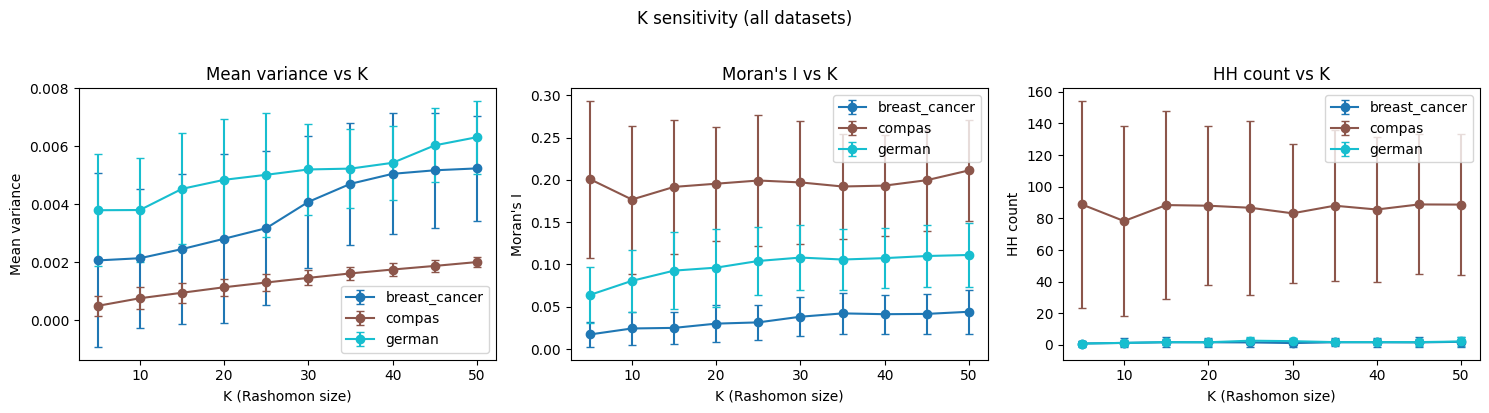

In [3]:
agg_k = df_k.groupby(["dataset", "K"]).agg(
    mean_variance_mean=("mean_variance", "mean"), mean_variance_std=("mean_variance", "std"),
    moran_mean=("moran_i", "mean"), moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"), n_hh_std=("n_hh", "std"),
).reset_index()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.tab10(np.linspace(0, 1, df_k["dataset"].nunique()))
for (ds, grp), c in zip(agg_k.groupby("dataset"), colors):
    d = grp
    ax1.errorbar(d["K"], d["mean_variance_mean"], yerr=d["mean_variance_std"], marker="o", capsize=3, label=ds, color=c)
    ax2.errorbar(d["K"], d["moran_mean"], yerr=d["moran_std"], marker="o", capsize=3, label=ds, color=c)
    ax3.errorbar(d["K"], d["n_hh_mean"], yerr=d["n_hh_std"], marker="o", capsize=3, label=ds, color=c)
ax1.set_xlabel("K (Rashomon size)"); ax1.set_ylabel("Mean variance"); ax1.set_title("Mean variance vs K"); ax1.legend()
ax2.set_xlabel("K (Rashomon size)"); ax2.set_ylabel("Moran's I"); ax2.set_title("Moran's I vs K"); ax2.legend()
ax3.set_xlabel("K (Rashomon size)"); ax3.set_ylabel("HH count"); ax3.set_title("HH count vs K"); ax3.legend()
fig.suptitle("K sensitivity (all datasets)", y=1.02)
fig.tight_layout()
plt.show()

## Interpret stability

If mean variance and Moran's I stabilize (flat or elbow) as K increases, the chosen K is not driving artifacts.